# Observable Signature searching
- this notebook looks for differences between whole cube projectionplots and the targetted bubble region projectionplot.

Begin by extracting a midplane square that contains the bubble

In [1]:
import matplotlib.pyplot as plt
import yt
import numpy as np
import os
from astropy import units as u
import cv2 as cv
from utils import *


# elephant
hdf5_root = "/srv/data/stratbox_simulations/stratbox_particle_runs/bx5/smd132/sn34/pe300/4pc_resume/4pc"
pplot_root = "/home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots"
# masks_root = "/home/joy0921/Desktop/Dataset/img_pix256/masks/SB-small/SN180-179-122"
masks_root = "/home/joy0921/Desktop/Dataset/img_pix256/masks/SB-large/SB230"

time_Myr = 210
dilate = True

ds = yt.load(os.path.join(hdf5_root, 'sn34_smd132_bx5_pe300_hdf5_plt_cnt_0{}'.format(time_Myr2timestamp(time_Myr))))

center = [0, 0, 0] * yt.units.pc
arb_center = ds.arr(center, 'code_length')
xlim, ylim, zlim = 256, 256, 256
left_edge = arb_center + ds.quan(-500, 'pc')        
right_edge = arb_center + ds.quan(500, 'pc')
obj = ds.arbitrary_grid(left_edge, right_edge, dims=(xlim,ylim,zlim))

print(obj["flash", "dens"].shape)

yt : [INFO     ] 2024-09-20 14:40:22,640 Particle file found: sn34_smd132_bx5_pe300_hdf5_part_0390
yt : [INFO     ] 2024-09-20 14:40:22,704 Parameters: current_time              = 6627195108709764.0
yt : [INFO     ] 2024-09-20 14:40:22,705 Parameters: domain_dimensions         = [  32   32 1280]
yt : [INFO     ] 2024-09-20 14:40:22,707 Parameters: domain_left_edge          = [-1.54283879e+21 -1.54283879e+21 -6.17135516e+22]
yt : [INFO     ] 2024-09-20 14:40:22,709 Parameters: domain_right_edge         = [1.54283879e+21 1.54283879e+21 6.17135516e+22]
yt : [INFO     ] 2024-09-20 14:40:22,710 Parameters: cosmological_simulation   = 0


(256, 256, 256)


# Projection plots
- then projection plot both the cube

yt : [INFO     ] 2024-09-18 10:01:39,296 Projection completed
yt : [INFO     ] 2024-09-18 10:01:39,301 xlim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-18 10:01:39,302 ylim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-18 10:01:39,305 xlim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-18 10:01:39,306 ylim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-18 10:01:39,309 Making a fixed resolution buffer of (('flash', 'dens')) 800 by 800



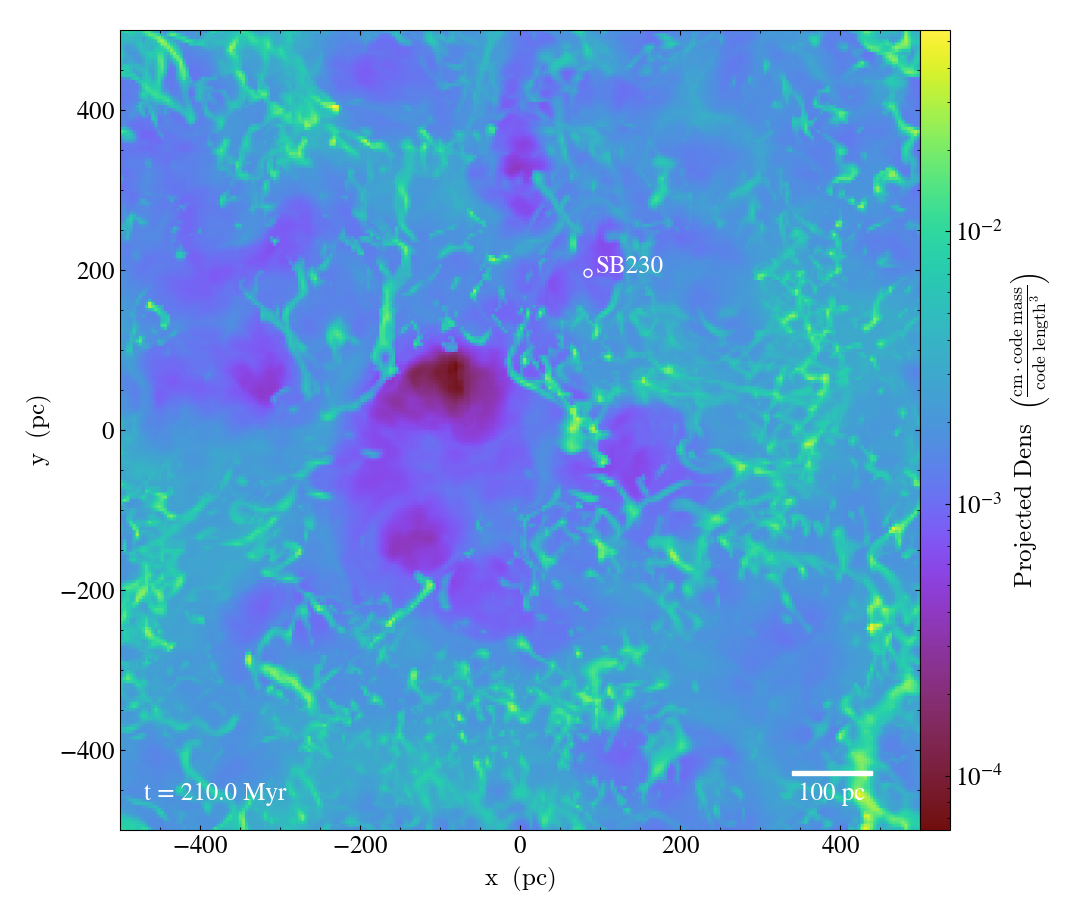

yt : [INFO     ] 2024-09-18 10:01:39,959 Saving plot /home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/210_cube.png


['/home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/210_cube.png']

In [27]:
prj = yt.ProjectionPlot(ds, 'z', 'dens', center = [0, 0, 0] * yt.units.pc)
# prj.annotate_marker([85, 196, 53], marker = 'x', color = 'red', plot_args = {'markersize': 10})

pos = (85, 400, 0)
# prj.annotate_marker(pos)#, marker='x', coord_system='plot', plot_args={'color': 'red', 's': 100})
# prj.annotate_marker([85, 196, 53], marker='x') #, coord_system = 'plot') #, plot_args={'s': 10, 'color':'red'})
prj.annotate_sphere([85, 196], radius=(5, "pc"), coord_system="plot", text="")
prj.annotate_text([85 + 10, 196], "SB230", coord_system="plot")

prj.annotate_timestamp()
prj.annotate_scale()

prj.show()

filename = f"{time_Myr}_cube"

prj.save(os.path.join(pplot_root, f'{filename}.png'))

In [2]:
def get_velz_dens(obj, x_range, y_range, z_range):
    # read a 3D grid of velz and density array
    velz = obj["flash", "velz"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value        
    dens = obj["flash", "dens"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('g/cm**3').value        
    temp = obj["flash", "temp"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('K').value 

    print(f"obj.shape: {obj['flash', 'velz'].shape}")
    print("x, y, z ranges: ", x_range, y_range, z_range)
    print(f"velz.shape: {velz.shape}\tdens.shape: {dens.shape}\n\n")      
     

    dz = obj['flash', 'dz'][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('cm').value
    mp = yt.physical_constants.mp.value # proton mass

    # calculate the density as column density
    coldens = dens * dz / (1.4 * mp)

    return velz, coldens, temp

and the target bubble

obj.shape: (256, 256, 256)
x, y, z ranges:  (0, 256) (0, 256) (0, 256)
velz.shape: (256, 256, 256)	dens.shape: (256, 256, 256)




yt : [INFO     ] 2024-09-20 14:43:06,407 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-09-20 14:43:06,410 Parameters: domain_dimensions         = [256 256 256]
yt : [INFO     ] 2024-09-20 14:43:06,412 Parameters: domain_left_edge          = [-500. -500. -500.]
yt : [INFO     ] 2024-09-20 14:43:06,413 Parameters: domain_right_edge         = [500. 500. 500.]
yt : [INFO     ] 2024-09-20 14:43:06,414 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-09-20 14:43:08,610 Projection completed
yt : [INFO     ] 2024-09-20 14:43:08,613 xlim = -500.000000 500.000000
yt : [INFO     ] 2024-09-20 14:43:08,614 ylim = -500.000000 500.000000
yt : [INFO     ] 2024-09-20 14:43:08,619 xlim = -500.000000 500.000000
yt : [INFO     ] 2024-09-20 14:43:08,619 ylim = -500.000000 500.000000
yt : [INFO     ] 2024-09-20 14:43:08,624 Making a fixed resolution buffer of (('stream', 'dens')) 800 by 800



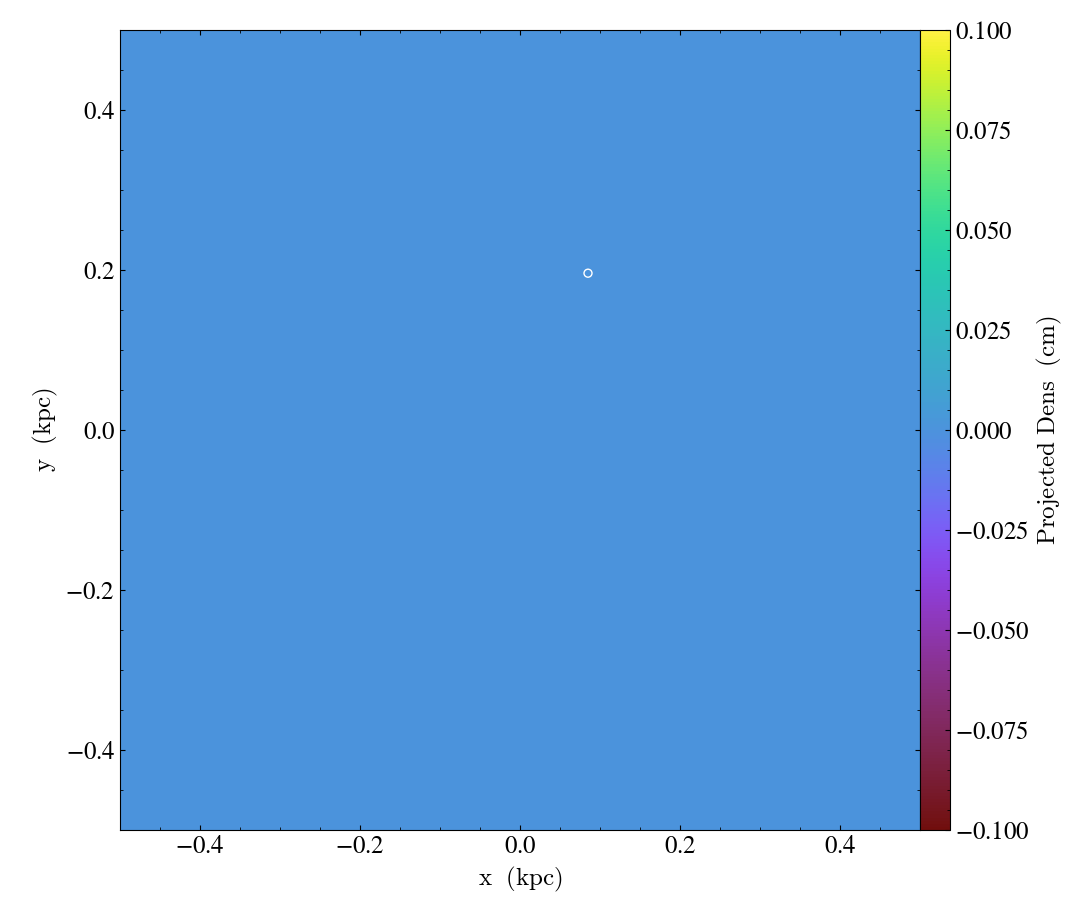

yt : [INFO     ] 2024-09-20 14:43:09,138 Saving plot /home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/210_target.png


['/home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/210_target.png']

In [4]:
# Load the density array 

_, dens_cube, _ = get_velz_dens(obj, (0, 256), (0, 256), (0, 256))
density_array = obj['flash', 'dens']


# Path to masks directory
mask_dir = os.path.join(masks_root, str(time_Myr2timestamp(time_Myr)))
density_target = np.zeros((256, 256, 256))

mask_cube = np.zeros((256, 256, 256))


# Iterate through all mask files (0.png to 255.png)
for z in range(256):
    mask_path = os.path.join(mask_dir, f"{z}.png")
    
    # Load the mask image and convert to a binary mask (1 for the region of interest, 0 otherwise)
    mask_img = cv.imread(mask_path, cv.IMREAD_GRAYSCALE)  #.convert('L')
    

    if(dilate):
        kernel = np.ones((2, 2), np.uint8) 
        mask_img = cv2.dilate(mask_img, kernel, iterations=1) 

    mask = mask_img / 255  # Normalize to range [0, 1]

    
# Apply the mask to the corresponding z-slice of the density array
density_target = np.where(mask, dens_cube, 0)       # np.nan

# Create a yt dataset from the modified density array
data = {'dens': (density_target)}
bbox = np.array([[-500, 500], [-500, 500], [-500, 500]])

ds_target = yt.load_uniform_grid(data, density_target.shape, bbox=bbox, length_unit='pc', nprocs=12)


# Generate the projection plot
prj_target = yt.ProjectionPlot(ds_target, 'z', 'dens')#, width=256 * yt.units.pc)#, center=[128, 128, 128] * yt.units.pc)
prj_target.annotate_sphere([0.085,0.196], radius=(0.005, "kpc"), coord_system="plot", text="")
prj_target.annotate_text([85 + 10, 196], "SB230", coord_system="plot")


prj_target.show()

# prj.annotate_timestamp()
# prj.annotate_scale()

filename = f"{time_Myr}_target"

prj_target.save(os.path.join(pplot_root, f'{filename}.png'))


/tmp/ipykernel_1529548/1116117289.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(density_target[165]) )


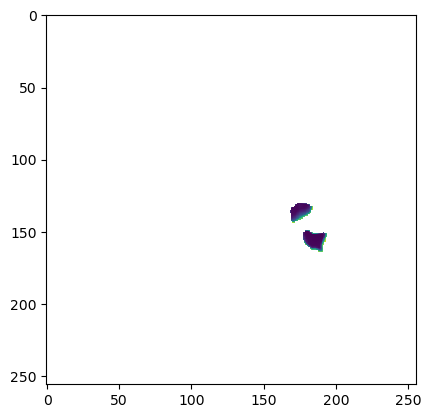

In [89]:
plt.imshow(np.log10(density_target[165]) )


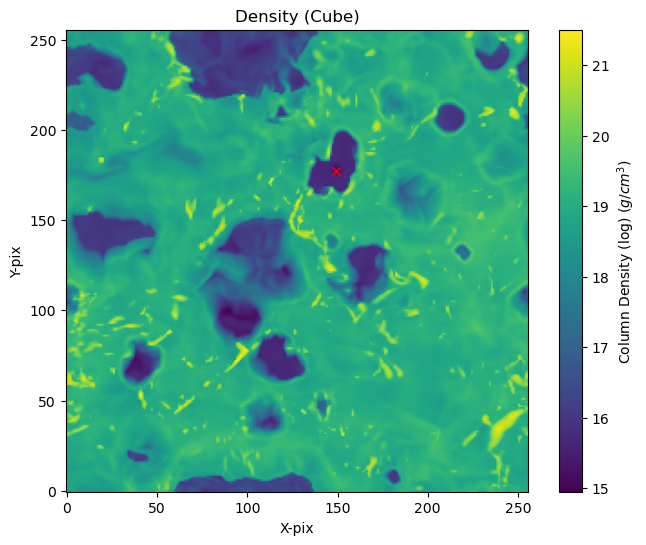

In [93]:
plt.figure(figsize=(8, 6))
# plt.imshow(np.rot90(np.log10(dens_cube[:, :, 141]), 0)  )
plt.imshow(np.log10(dens_cube[:, :, 131]).T, origin='lower') 
plt.plot(149,177, 'x:r')
plt.colorbar(label='Column Density (log) ($g/cm^3$)')
plt.title('Density (Cube)')
plt.xlabel('X-pix')
plt.ylabel('Y-pix')
plt.show()

/tmp/ipykernel_1529548/219090658.py:10: UserWarning: The following kwargs were not used by contour: 'level', 'color'
  contour = plt.contour(projection_target.T, level = [17e20], color = 'black')


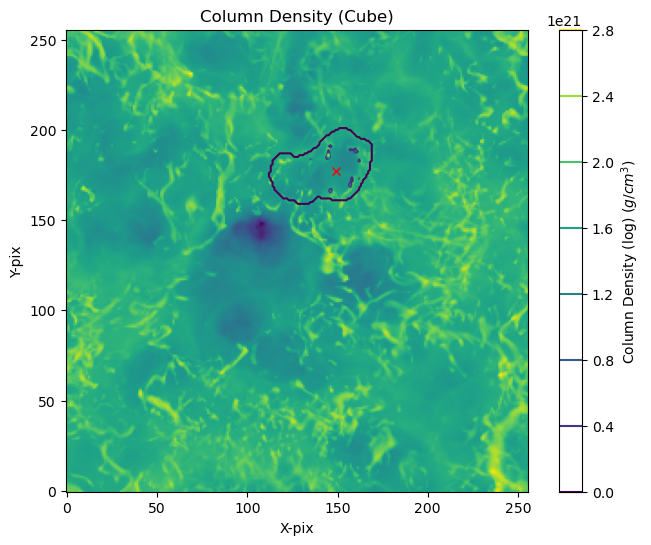

In [140]:

# Project along the z-axis by summing
projection_cube = np.sum(dens_cube , axis=2)  # Summing along the z-axis
projection_target = np.sum(density_target , axis=0)

# Plot the 2D projection
plt.figure(figsize=(8, 6))
plt.imshow(np.log10(projection_cube).T, cmap='viridis', origin='lower')
plt.plot(149,177, 'x:r')

# Contour for th bubble projection
contour = plt.contour(projection_target.T, level = [17e20], color = 'black')
# plt.clabel(contour, inline=True, fontsize=10)

my_xticks = [x * 4 for x in range(256)]

# plt.xticks(projection_cube[:, 0], my_xticks)
# plt.yticks(projection_cube[0, :], my_xticks)

plt.colorbar(label='Column Density (log) ($g/cm^3$)')
plt.title('Column Density (Cube)')
plt.xlabel('X-pix')
plt.ylabel('Y-pix')
plt.show()

filename = f"{time_Myr}_contour"
plt.savefig(os.path.join(pplot_root, f'{filename}.png'))

In [104]:
density_target.shape

(256, 256, 256)

/tmp/ipykernel_1529548/2055430602.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(projection_target).T, cmap='viridis', origin='lower')
/tmp/ipykernel_1529548/2055430602.py:10: UserWarning: The following kwargs were not used by contour: 'color'
  contour = plt.contour(projection_target.T, levels = my_levels, color = 'black')


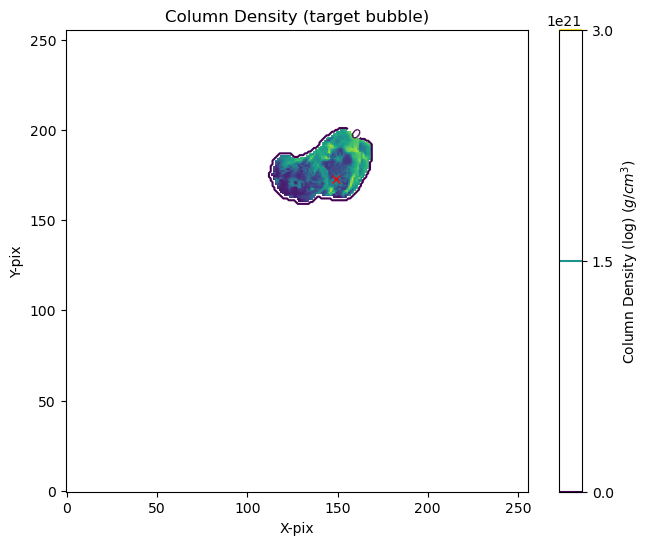

In [154]:
# Project along the z-axis by summing
projection_target = np.sum(density_target , axis=0)  # Summing along the z-axis

# Plot the 2D projection
plt.figure(figsize=(8, 6))
plt.imshow(np.log10(projection_target).T, cmap='viridis', origin='lower')
plt.plot(149,173, 'x:r')

my_levels = 1 #np.arange(1)
contour = plt.contour(projection_target.T, levels = my_levels, color = 'black')
plt.clabel(contour, inline=True, fontsize=10)

plt.colorbar(label='Column Density (log) ($g/cm^3$)')
plt.title('Column Density (target bubble)')
plt.xlabel('X-pix')
plt.ylabel('Y-pix')
plt.show()